© 2025 Mobile Perception Systems Lab at TU/e. All rights reserved. Licensed under the MIT License.

## Setup

In [69]:
%cd /content/drive/MyDrive/AnomalySegmentation_Project/eomt

/content/drive/MyDrive/AnomalySegmentation_Project/eomt


In [70]:
import yaml
from lightning import seed_everything
import torch
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast
import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import RepositoryNotFoundError
import warnings
import importlib

seed_everything(0, verbose=False)

device = 2  # TODO: change to the GPU you want to use
img_idx = 175 # TODO: change to the index of the image you want to visualize
config_path_coco = "configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml" 
config_path_cityscapes = "configs/dinov2/cityscapes/semantic/eomt_base_640.yaml" 
data_path = "../Cityscapes"  # TODO: change to the dataset directory

with open(config_path_coco, "r") as f:
    config_coco = yaml.safe_load(f)

with open(config_path_cityscapes, "r") as f:
    config_city = yaml.safe_load(f)

def create_mapping(images, ignore_index):
    unique_ids = np.unique(np.concatenate([np.unique(img) for img in images]))
    valid_ids = unique_ids[unique_ids != ignore_index]
    colors = np.array(
        [plt.cm.hsv(i / len(valid_ids))[:3] for i in range(len(valid_ids))]
    )
    mapping = {cid: colors[i] for i, cid in enumerate(valid_ids)}
    mapping[ignore_index] = np.array([0, 0, 0])
    return mapping


def apply_colormap(image, mapping):
    colored_image = np.zeros((*image.shape, 3))
    for cid in np.unique(image):
        colored_image[image == cid] = mapping.get(cid, [0, 0, 0])
    return colored_image

In [71]:
# Check if CUDA (NVIDIA GPU) is available
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("No GPU detected, using CPU.")


GPU detected: Tesla T4


## Load dataset

Ensure the dataset files are correctly prepared and placed in the folder specified by `data_path`.

In [72]:
#CITYSCAPES
data_module_name_city, class_name_city = config_city["data"]["class_path"].rsplit(".", 1)
data_module_city = getattr(importlib.import_module(data_module_name_city), class_name_city)
data_kwargs_city = config_city["data"].get("init_args", {})

data_city = data_module_city(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_kwargs_city
)
data_city.setup() 


#COCO
data_module_name_coco, class_name_coco = config_coco["data"]["class_path"].rsplit(".", 1)
data_module_coco = getattr(importlib.import_module(data_module_name_coco), class_name_coco)
data_kwargs_coco = config_coco["data"].get("init_args", {})

data_coco_meta = data_module_coco(
    path="",
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_kwargs_coco
)

print(data_kwargs_city)

{}


## Load model

In [73]:
warnings.filterwarnings(
    "ignore",
    message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
)

def build_and_load_model(config, data_meta, weights_path):
    # Load encoder
    encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
    encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
    encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
    encoder = encoder_cls(img_size=data_meta.img_size, **encoder_cfg.get("init_args", {}))

    # Load network
    network_cfg = config["model"]["init_args"]["network"]
    network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
    network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
    network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}
    
    network = network_cls(
        masked_attn_enabled=False,
        num_classes=data_meta.num_classes,
        encoder=encoder,
        **network_kwargs,
    )

    # Load Lightning module
    lit_module_name, lit_class_name = config["model"]["class_path"].rsplit(".", 1)
    lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
    model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}
    
    if "stuff_classes" in config["data"].get("init_args", {}):
        model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

    name = config.get("trainer", {}).get("logger", {}).get("init_args", {}).get("name", "")
    is_dinov3 = "dinov3" in name

    if is_dinov3:
        model_kwargs["ckpt_path"] = weights_path
        model_kwargs["delta_weights"] = True

    model = (
        lit_cls(
            img_size=data_meta.img_size,
            num_classes=data_meta.num_classes,
            network=network,
            **model_kwargs,
        )
        .eval()
        .to(device)
    )
    
    if not is_dinov3:
        try:
            state_dict = torch.load(weights_path, map_location=device, weights_only=True)
            model.load_state_dict(state_dict, strict=False)
            print(f"Weights successfully loaded from {weights_path}!")
        except Exception as e:
            print(f"Error loading weights from {weights_path}: {e}")
            
    return model

#COCO
state_dict_path_coco = "weights/eomt_coco.bin"
print("Initializing COCO Panoptic model...")
model_panoptic = build_and_load_model(config_coco, data_coco_meta, state_dict_path_coco)

#CITYSCAPES
state_dict_path_city = "weights/eomt_cityscapes.bin"
print("Initializing Cityscapes Semantic model...")
model_semantic = build_and_load_model(config_city, data_city, state_dict_path_city)

Initializing COCO Panoptic model...
Weights successfully loaded from weights/eomt_coco.bin!
Initializing Cityscapes Semantic model...
Weights successfully loaded from weights/eomt_cityscapes.bin!


## Semantic inference (pixel-wise classification)

> This inference method also works when applied to a model trained for panoptic segmentation.

Semantic inference computes per-pixel class scores by combining mask and class predictions:

$$
\sum_i p_i(c) \cdot m_i[h, w]
$$

Here, $p_i(c)$ is the class probability for class $c$ (excluding "no object"), and $m_i[h, w]$ is the sigmoid-normalized mask value for query $i$ at pixel $(h, w)$. The final class is selected by taking the argmax over classes.  
  
*This inference method was originally introduced in MaskFormer.*

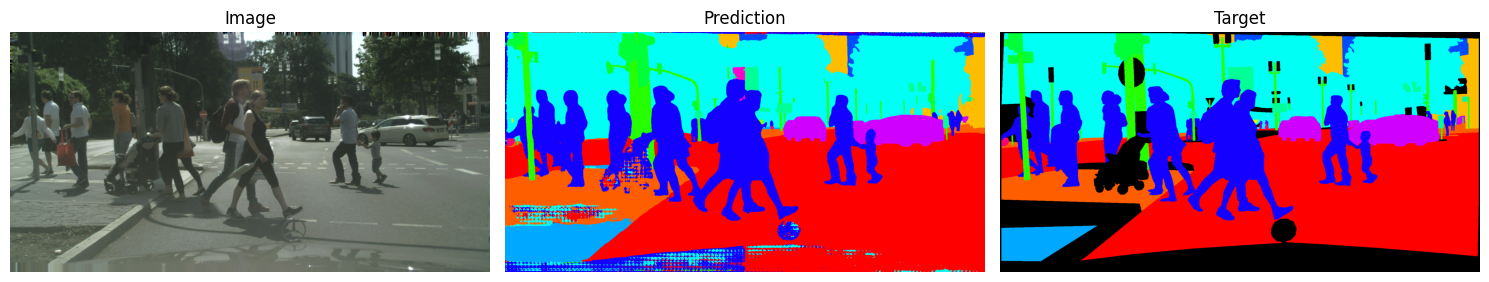

In [74]:
IGNORE_INDEX = 255

def infer_semantic(model_sem, data_val, img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]
        
        crops, origins = model_sem.window_imgs_semantic(imgs)

        mask_logits_per_layer, class_logits_per_layer = model_sem(crops)
        
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], data_val.img_size, mode="bilinear"
        )

        crop_logits = model_sem.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model_sem.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()
    target_array = model_sem.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[
        0
    ].numpy()
    return pred_array, target_array


def plot_semantic_results(img, pred_array, target_array):
    mapping = create_mapping([pred_array, target_array], IGNORE_INDEX)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Image")
    axes[1].imshow(apply_colormap(pred_array, mapping))
    axes[1].set_title("Prediction")
    axes[2].imshow(apply_colormap(target_array, mapping))
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

img, target = data_city.val_dataloader().dataset[img_idx]
pred_array, target_array = infer_semantic(model_semantic, data_city, img, target)
plot_semantic_results(img, pred_array, target_array)

## Panoptic inference (segmentation with instance IDs)

> This inference method also works when applied to a model trained for instance segmentation.

Panoptic inference assigns each pixel $[h, w]$ to the query $i$ that maximizes the product of class and mask confidence:

$$
p_i(c_i) \cdot m_i[h, w]
$$

where $c_i = \arg\max_c \, p_i(c)$ is the most likely class for query $i$. A pixel is assigned to a query only if both the class confidence and mask confidence are high. Pixels assigned to the same query form a segment labeled with $c_i$. "Stuff" segments with the same class are merged; "thing" segments are kept distinct using the query index. Low-confidence and heavily occluded predictions are filtered out.  
  
*This inference method was originally introduced in MaskFormer.*

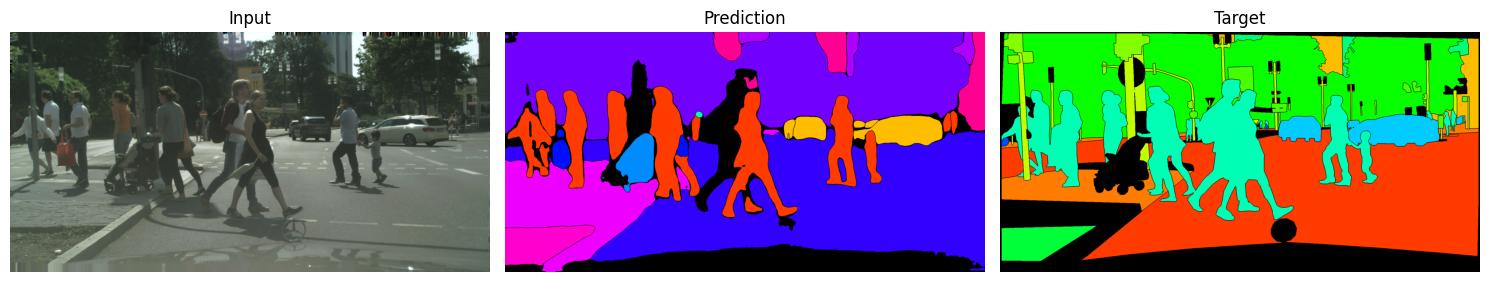

In [75]:
def infer_panoptic(model_pan, img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]

        transformed_imgs = model_pan.resize_and_pad_imgs_instance_panoptic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model_pan(transformed_imgs)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], model_pan.img_size, mode="bilinear"
        )
        mask_logits = model_pan.revert_resize_and_pad_logits_instance_panoptic(
            mask_logits, img_sizes
        )

        preds = model_pan.to_per_pixel_preds_panoptic(
            mask_logits,
            class_logits_per_layer[-1],
            model_pan.stuff_classes,
            model_pan.mask_thresh,
            model_pan.overlap_thresh,
        )[0].cpu()

    pred = preds.numpy()
    sem_pred, inst_pred = pred[..., 0], pred[..., 1]

    target_seg = model_pan.to_per_pixel_targets_panoptic([target])[0].cpu().numpy()
    sem_target, inst_target = target_seg[..., 0], target_seg[..., 1]

    return sem_pred, inst_pred, sem_target, inst_target


def draw_black_border(sem, inst, mapping):
    h, w = sem.shape
    out = np.zeros((h, w, 3))
    for s in np.unique(sem):
        out[sem == s] = mapping[s]

    combined = sem.astype(np.int64) * 100000 + inst.astype(np.int64)
    border = np.zeros((h, w), dtype=bool)
    border[1:, :] |= combined[1:, :] != combined[:-1, :]
    border[:-1, :] |= combined[1:, :] != combined[:-1, :]
    border[:, 1:] |= combined[:, 1:] != combined[:, :-1]
    border[:, :-1] |= combined[:, 1:] != combined[:, :-1]
    out[border] = 0
    return out


def plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target, num_classes):
    all_ids = np.union1d(np.unique(sem_pred), np.unique(sem_target))
    mapping = {
        s: (
            [0, 0, 0]
            if s == -1 or s == num_classes
            else plt.cm.hsv(i / len(all_ids))[:3]
        )
        for i, s in enumerate(all_ids)
    }

    vis_pred = draw_black_border(sem_pred, inst_pred, mapping)
    vis_target = draw_black_border(sem_target, inst_target, mapping)

    img_np = (
        img.cpu().numpy().transpose(1, 2, 0) if img.dim() == 3 else img.cpu().numpy()
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_np)
    axes[0].set_title("Input")
    axes[1].imshow(vis_pred)
    axes[1].set_title("Prediction")
    axes[2].imshow(vis_target)
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


img, target = data_city.val_dataloader().dataset[img_idx]
sem_pred, inst_pred, sem_target, inst_target = infer_panoptic(model_panoptic, img, target)
plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target, model_panoptic.num_classes)

# Only Common Classes

In [76]:
from torchmetrics.classification import MulticlassJaccardIndex
from tqdm import tqdm

IGNORE_INDEX = 255

# 1. EVALUATION STRATEGY
# num_classes=20 (Indices 0-18: Cityscapes classes, Index 19: Sink class for errors and non-matching labels).
metric_city = MulticlassJaccardIndex(num_classes=20, ignore_index=IGNORE_INDEX, average="none").to(device)
metric_coco = MulticlassJaccardIndex(num_classes=20, ignore_index=IGNORE_INDEX, average="none").to(device)

# 2. CREATE AND POPULATE MAPPING TENSOR (Size 256 for crash prevention, initialized with 19)
mapping_tensor = torch.full((256,), 19, dtype=torch.long, device=device)

# Map COCO prediction indices to the corresponding Cityscapes IDs
mapping_tensor[0] = 11   # person -> person
mapping_tensor[1] = 18   # bicycle -> bicycle
mapping_tensor[2] = 13   # car -> car
mapping_tensor[3] = 17   # motorcycle -> motorcycle
mapping_tensor[5] = 15   # bus -> bus
mapping_tensor[6] = 16   # train -> train
mapping_tensor[7] = 14   # truck -> truck
mapping_tensor[9] = 6    # traffic light -> traffic light
mapping_tensor[100] = 0  # road -> road (corrected from 100/110)
mapping_tensor[119] = 10 # sky -> sky (corrected from 105)

# 3. EVALUATION LOOP
val_dataloader = data_city.val_dataloader()

model_semantic.eval()
model_panoptic.eval()

print("Starting quantitative mIoU evaluation (Shared classes only)...")

for batch_idx, batch in enumerate(tqdm(val_dataloader, desc="Processing")):
    batched_imgs, batched_targets = batch
    img = batched_imgs[0]
    target = batched_targets[0]
    
    # --- Cityscapes Model (Native) ---
    preds_city_np, target_array_np = infer_semantic(model_semantic, data_city, img, target)
    
    preds_city_tensor = torch.tensor(preds_city_np, device=device)
    target_tensor = torch.tensor(target_array_np, device=device)
    metric_city.update(preds_city_tensor, target_tensor)

    # --- COCO Model (Mapped) ---
    preds_coco_np, _ = infer_semantic(model_panoptic, data_coco_meta, img, target)
    preds_coco_tensor = torch.tensor(preds_coco_np, device=device)
    
    # Instant vectorized mapping
    preds_mapped_tensor = mapping_tensor[preds_coco_tensor]
    metric_coco.update(preds_mapped_tensor, target_tensor)

# 4. RESULTS CALCULATION AND DISPLAY
iou_array_city = metric_city.compute()
iou_array_coco = metric_coco.compute()

common_ids = [0, 6, 10, 11, 13, 14, 15, 16, 17, 18]
names = ["road", "traffic light", "sky", "person", "car", "truck", "bus", "train", "motorcycle", "bicycle"]

print("\n" + "-"*65)
print(f"{'CLASS':<20} | {'Cityscapes IoU (%)':<20} | {'COCO IoU (%)':<20}")
print("-"*65)

for cid, name in zip(common_ids, names):
    val_city = iou_array_city[cid].item() * 100
    val_coco = iou_array_coco[cid].item() * 100
    print(f"{name:<20} | {val_city:<20.2f} | {val_coco:<20.2f}")

# Final mIoU calculation for shared classes
print("-"*65)
print(f"{'TOTAL mIoU':<20} | {torch.nanmean(iou_array_city[common_ids]).item()*100:<20.2f} | {torch.nanmean(iou_array_coco[common_ids]).item()*100:<20.2f}")
print("-"*65)

metric_city.reset()
metric_coco.reset()

Starting quantitative mIoU evaluation (Shared classes only)...


Processing:   0%|          | 0/500 [00:00<?, ?it/s]

Processing: 100%|██████████| 500/500 [06:45<00:00,  1.23it/s]


-----------------------------------------------------------------
CLASS                | Cityscapes IoU (%)   | COCO IoU (%)        
-----------------------------------------------------------------
road                 | 98.40                | 94.01               
traffic light        | 75.00                | 60.37               
sky                  | 95.54                | 89.70               
person               | 85.38                | 67.22               
car                  | 95.54                | 84.22               
truck                | 81.79                | 29.34               
bus                  | 90.32                | 71.16               
train                | 77.35                | 13.61               
motorcycle           | 74.35                | 63.59               
bicycle              | 81.27                | 72.20               
-----------------------------------------------------------------
TOTAL mIoU           | 85.50                | 64.54             